In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cats_dogs_light.zip to cats_dogs_light.zip


In [ ]:
import os
os.listdir()

['.config', 'cats_dogs_light.zip', 'sample_data']

In [ ]:
import zipfile

with zipfile.ZipFile("cats_dogs_light.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import os

print(os.listdir("/content/dataset"))

['cats_dogs_light']


In [ ]:
train_path = "/content/dataset/cats_dogs_light/train"
test_path  = "/content/dataset/cats_dogs_light/test"

In [ ]:
import os
import shutil

base_dir = "/content/dataset/cats_dogs_light/train"

cat_dir = os.path.join(base_dir, "cats")
dog_dir = os.path.join(base_dir, "dogs")

os.makedirs(cat_dir, exist_ok=True)
os.makedirs(dog_dir, exist_ok=True)

for file in os.listdir(base_dir):
    if file.startswith("cat"):
        shutil.move(os.path.join(base_dir, file), cat_dir)
    elif file.startswith("dog"):
        shutil.move(os.path.join(base_dir, file), dog_dir)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),

    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 97s 4s/step - accuracy: 0.5337 - loss: 0.7119 - val_accuracy: 0.5700 - val_loss: 0.6869
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.5562 - loss: 0.6867 - val_accuracy: 0.5450 - val_loss: 0.6892
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.5612 - loss: 0.6694 - val_accuracy: 0.5400 - val_loss: 0.6841
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.5825 - loss: 0.6650 - val_accuracy: 0.6250 - val_loss: 0.6883
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.5913 - loss: 0.6440 - val_accuracy: 0.6500 - val_loss: 0.6228
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.6463 - loss: 0.6217 - val_accuracy: 0.6800 - val_loss: 0.6138
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.6900 - loss: 0.5887 - val_accuracy: 0.6600 - val_loss: 0.6124
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.7088 - loss: 0.5335 - val_accuracy: 0.6650 - val_loss:

In [ ]:
loss, acc = model.evaluate(val_data)
print("Accuracy:", acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 894ms/step - accuracy: 0.7150 - loss: 0.7267
Accuracy: 0.7149999737739563


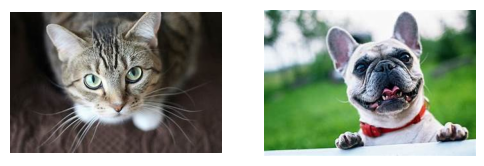

In [ ]:
import matplotlib.pyplot as plt

img1 = plt.imread("/content/test.jpg")
img2 = plt.imread("/content/test2.jpg")

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.axis("off")

plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
from google.colab import files
files.upload()

Saving test.jpg to test.jpg


{'test.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\n\x07\x07\t\x07\x06\n\t\x08\t\x0b\x0b\n\x0c\x0f\x19\x10\x0f\x0e\x0e\x0f\x1e\x16\x17\x12\x19$ &%# #"(-90(*6+"#2D26;=@@@&0FKE>J9?@=\xff\xdb\x00C\x01\x0b\x0b\x0b\x0f\r\x0f\x1d\x10\x10\x1d=)#)==================================================\xff\xc0\x00\x11\x08\x00\xdc\x01J\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\xd4\xd5\xd6\xd7\xd8\xd9\xda\xe

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'dataset', 'cats_dogs_light.zip', 'test.jpg', 'sample_data']


In [ ]:
img_path = "/content/test.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Cat 🐱


In [ ]:
from google.colab import files
files.upload()

Saving test2.jpg to test2.jpg


{'test2.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\n\x07\x07\t\x07\x06\n\t\x08\t\x0b\x0b\n\x0c\x0f\x19\x10\x0f\x0e\x0e\x0f\x1e\x16\x17\x12\x19$ &%# #"(-90(*6+"#2D26;=@@@&0FKE>J9?@=\xff\xdb\x00C\x01\x0b\x0b\x0b\x0f\r\x0f\x1d\x10\x10\x1d=)#)==================================================\xff\xc0\x00\x11\x08\x00\xdc\x01>\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\xd4\xd5\xd6\xd7\xd8\xd9\xda\x

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'dataset', 'cats_dogs_light.zip', 'test2.jpg', 'test.jpg', 'sample_data']


In [ ]:
img_path = "/content/test2.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

print("Raw output:", prediction[0])

if prediction[0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Raw output: [0.9774391]
Dog 🐶
